# Bitcoin Market Sentiment vs Trader Performance

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

fear = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

print("Fear & Greed Data")
print(fear.head())

print("\nTrader Data")
print(trades.head())

fear["date"] = pd.to_datetime(fear["date"])

trades["Timestamp IST"] = pd.to_datetime(
    trades["Timestamp IST"],
    dayfirst=True
)

trades["Date"] = trades["Timestamp IST"].dt.normalize()

fear = fear.rename(columns={
    "date": "Date",
    "classification": "Sentiment"
})

data = pd.merge(
    trades,
    fear[["Date", "Sentiment"]],
    on="Date",
    how="left"
)

print("\nMerged Data")
print(data.head())

data["Closed PnL"] = pd.to_numeric(data["Closed PnL"], errors="coerce")
data["Execution Price"] = pd.to_numeric(data["Execution Price"], errors="coerce")
data["Size USD"] = pd.to_numeric(data["Size USD"], errors="coerce")
data["Size Tokens"] = pd.to_numeric(data["Size Tokens"], errors="coerce")
data["Fee"] = pd.to_numeric(data["Fee"], errors="coerce")
7
data["Closed PnL"] = data["Closed PnL"].fillna(0)
data["Execution Price"] = data["Execution Price"].fillna(0)
data["Size USD"] = data["Size USD"].fillna(0)
data["Size Tokens"] = data["Size Tokens"].fillna(0)
data["Fee"] = data["Fee"].fillna(0)

data["Sentiment"] = data["Sentiment"].fillna("Unknown")

print("\nDataset Shape")
print(data.shape)

print("\nMissing Values")
print(data.isnull().sum())

print("\nStatistics")
print(data[["Closed PnL","Execution Price","Size USD","Size Tokens","Fee"]].describe())

print("\nSentiment Count")
print(data["Sentiment"].value_counts())

print("\nBuy / Sell Count")
print(data["Side"].value_counts())

print("\nTop Coins")
print(data["Coin"].value_counts().head(10))

profit = data[data["Closed PnL"] > 0]
loss = data[data["Closed PnL"] < 0]

print("\nTotal Trades:", len(data))
print("Profit Trades:", len(profit))
print("Loss Trades:", len(loss))
print("Net PnL:", data["Closed PnL"].sum())

Fear & Greed Data
    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05

Trader Data
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   


Average Profit/Loss by Sentiment
Sentiment
Extreme Fear       34.537862
Extreme Greed      67.892861
Fear               54.290400
Greed              42.743559
Neutral            34.307718
Unknown          7078.665688
Name: Closed PnL, dtype: float64


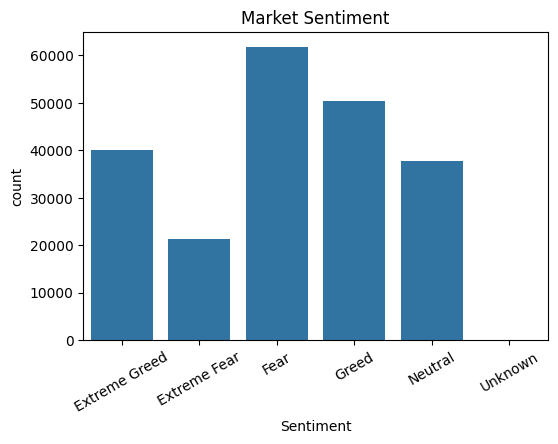

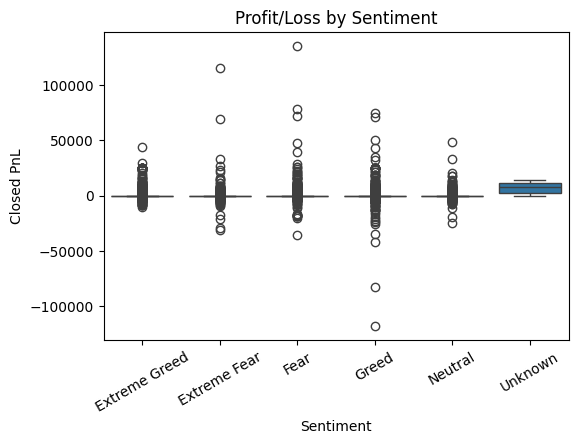

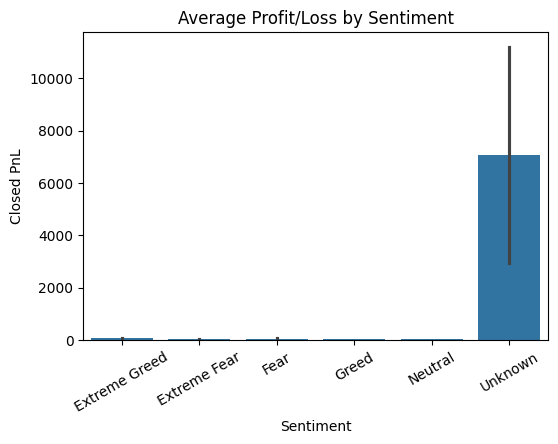

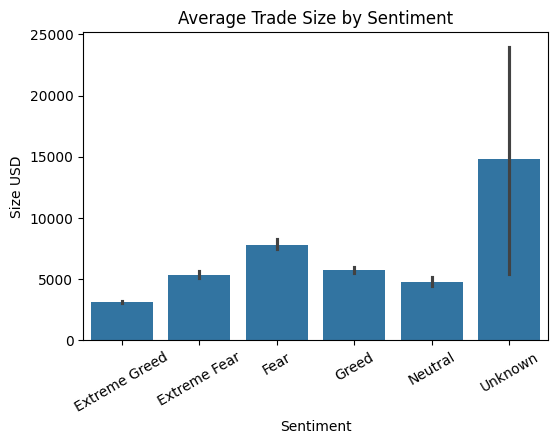

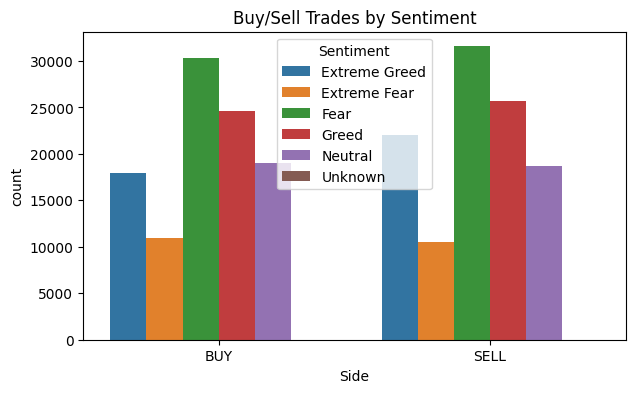

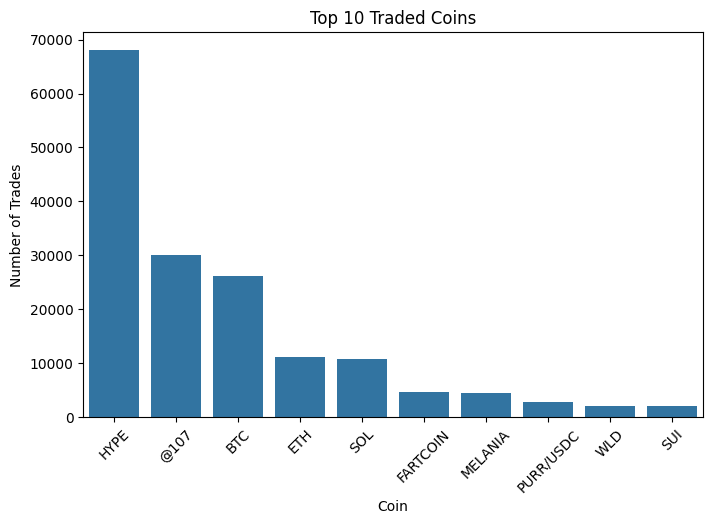

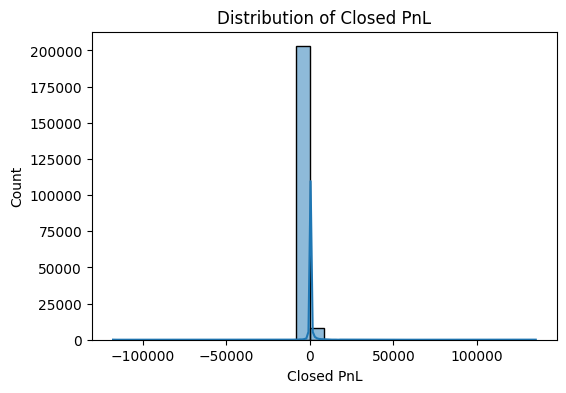

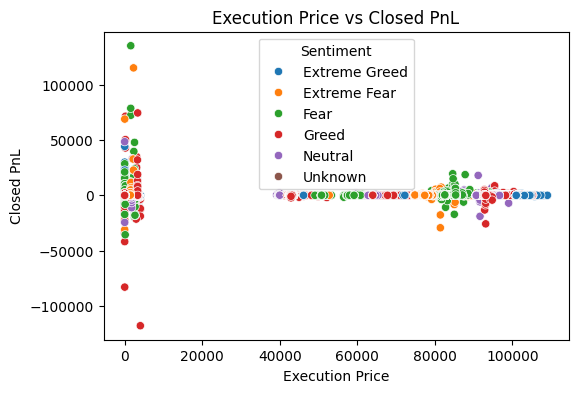


Average Trade Size by Sentiment
Sentiment
Extreme Fear      5349.731843
Extreme Greed     3112.251565
Fear              7816.109931
Greed             5736.884375
Neutral           4782.732661
Unknown          14778.143333
Name: Size USD, dtype: float64

Average Profit by Buy/Sell
Side
BUY     36.104730
SELL    60.713803
Name: Closed PnL, dtype: float64

Top 10 Coins by Total Profit
Coin
@107       2.783913e+06
HYPE       1.948485e+06
SOL        1.639556e+06
ETH        1.319979e+06
BTC        8.680447e+05
MELANIA    3.903511e+05
ENA        2.173295e+05
SUI        1.992688e+05
ZRO        1.837778e+05
DOGE       1.475432e+05
Name: Closed PnL, dtype: float64


In [ ]:

data["Sentiment"] = data["Sentiment"].fillna("Unknown")
data["Sentiment"] = data["Sentiment"].replace(0, "Unknown")
data["Sentiment"] = data["Sentiment"].astype(str)

print("\nAverage Profit/Loss by Sentiment")
print(data.groupby("Sentiment")["Closed PnL"].mean())

plt.figure(figsize=(6,4))
sns.countplot(data=data, x="Sentiment")
plt.title("Market Sentiment")
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(data=data, x="Sentiment", y="Closed PnL")
plt.title("Profit/Loss by Sentiment")
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(6,4))
sns.barplot(data=data, x="Sentiment", y="Closed PnL", estimator="mean")
plt.title("Average Profit/Loss by Sentiment")
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(6,4))
sns.barplot(data=data, x="Sentiment", y="Size USD", estimator="mean")
plt.title("Average Trade Size by Sentiment")
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(7,4))
sns.countplot(data=data, x="Side", hue="Sentiment")
plt.title("Buy/Sell Trades by Sentiment")
plt.show()

top = data["Coin"].value_counts().head(10)

plt.figure(figsize=(8,5))
sns.barplot(x=top.index, y=top.values)
plt.xticks(rotation=45)
plt.xlabel("Coin")
plt.ylabel("Number of Trades")
plt.title("Top 10 Traded Coins")
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(data["Closed PnL"], bins=30, kde=True)
plt.title("Distribution of Closed PnL")
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(
    data=data,
    x="Execution Price",
    y="Closed PnL",
    hue="Sentiment"
)
plt.title("Execution Price vs Closed PnL")
plt.show()

print("\nAverage Trade Size by Sentiment")
print(data.groupby("Sentiment")["Size USD"].mean())

print("\nAverage Profit by Buy/Sell")
print(data.groupby("Side")["Closed PnL"].mean())

print("\nTop 10 Coins by Total Profit")
print(
    data.groupby("Coin")["Closed PnL"]
        .sum()
        .sort_values(ascending=False)
        .head(10)
)


Win Rate by Sentiment
Sentiment
Extreme Fear      37.060748
Extreme Greed     46.494299
Fear              42.076750
Greed             38.482794
Neutral           39.699093
Unknown          100.000000
Name: Closed PnL, dtype: float64

Total Profit/Loss by Sentiment
Sentiment
Extreme Fear     7.391102e+05
Extreme Greed    2.715171e+06
Fear             3.357155e+06
Greed            2.150129e+06
Neutral          1.292921e+06
Unknown          4.247199e+04
Name: Closed PnL, dtype: float64

Top 10 Profitable Coins
Coin
@107       2.783913e+06
HYPE       1.948485e+06
SOL        1.639556e+06
ETH        1.319979e+06
BTC        8.680447e+05
MELANIA    3.903511e+05
ENA        2.173295e+05
SUI        1.992688e+05
ZRO        1.837778e+05
DOGE       1.475432e+05
Name: Closed PnL, dtype: float64


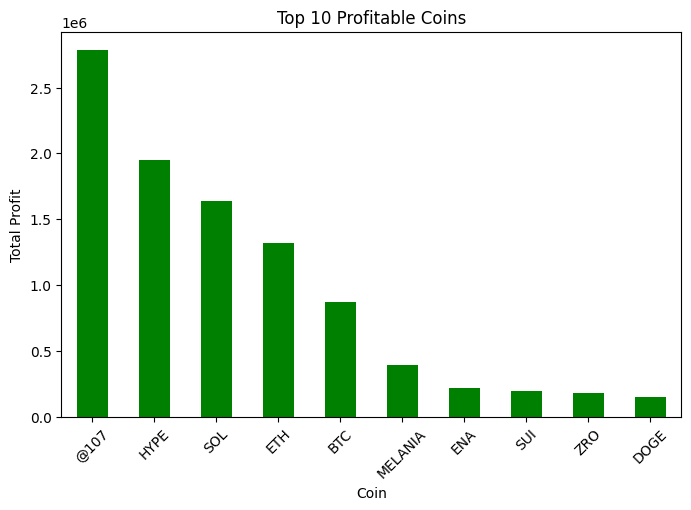


Top 10 Loss Making Coins
Coin
TRUMP      -364824.908179
FARTCOIN   -100687.213185
ADA         -28113.461970
IO          -21893.910518
PAXG        -18688.874329
KAITO        -8735.140961
S            -8644.845718
POPCAT       -7922.181871
@135         -5981.363990
NIL          -3175.273635
Name: Closed PnL, dtype: float64


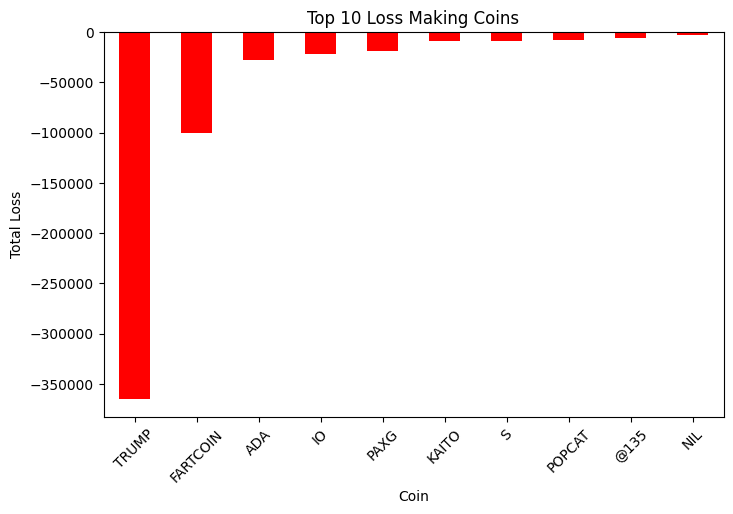


----- Final Insights -----
Average Profit in Fear Market : 54.29039962549929
Average Profit in Greed Market : 42.74355948851957
Traders performed better during Fear periods.
Overall Net Profit/Loss : 10296958.943436
Average Trade Size : 5639.451210373822
Average Execution Price : 11414.72334999376

Top 5 Coins by Number of Trades
Coin
HYPE    68005
@107    29992
BTC     26064
ETH     11158
SOL     10691
Name: count, dtype: int64

Average Profit by Buy/Sell
Side
BUY     36.104730
SELL    60.713803
Name: Closed PnL, dtype: float64


In [13]:
print("\nWin Rate by Sentiment")

win_rate = data.groupby("Sentiment")["Closed PnL"].apply(lambda x: (x > 0).mean() * 100)
print(win_rate)

print("\nTotal Profit/Loss by Sentiment")
print(data.groupby("Sentiment")["Closed PnL"].sum())

print("\nTop 10 Profitable Coins")

top_profit = data.groupby("Coin")["Closed PnL"].sum().sort_values(ascending=False)
print(top_profit.head(10))

plt.figure(figsize=(8,5))
top_profit.head(10).plot(kind="bar", color="green")
plt.title("Top 10 Profitable Coins")
plt.xlabel("Coin")
plt.ylabel("Total Profit")
plt.xticks(rotation=45)
plt.show()

print("\nTop 10 Loss Making Coins")

top_loss = data.groupby("Coin")["Closed PnL"].sum().sort_values()
print(top_loss.head(10))

plt.figure(figsize=(8,5))
top_loss.head(10).plot(kind="bar", color="red")
plt.title("Top 10 Loss Making Coins")
plt.xlabel("Coin")
plt.ylabel("Total Loss")
plt.xticks(rotation=45)
plt.show()

data.to_csv("merged_analysis.csv", index=False)

print("\n----- Final Insights -----")

avg_fear = data[data["Sentiment"] == "Fear"]["Closed PnL"].mean()
avg_greed = data[data["Sentiment"] == "Greed"]["Closed PnL"].mean()

print("Average Profit in Fear Market :", avg_fear)
print("Average Profit in Greed Market :", avg_greed)

if pd.notna(avg_fear) and pd.notna(avg_greed):
    if avg_fear > avg_greed:
        print("Traders performed better during Fear periods.")
    else:
        print("Traders performed better during Greed periods.")
else:
    print("Not enough data to compare Fear and Greed.")

print("Overall Net Profit/Loss :", data["Closed PnL"].sum())
print("Average Trade Size :", data["Size USD"].mean())
print("Average Execution Price :", data["Execution Price"].mean())

print("\nTop 5 Coins by Number of Trades")
print(data["Coin"].value_counts().head())

print("\nAverage Profit by Buy/Sell")
print(data.groupby("Side")["Closed PnL"].mean())
